# Task 2: Feature Engineering, Model Optimization & Performance Comparison

**Intern:** Ravindra Das  
**Domain:** Artificial Intelligence & Machine Learning  
**Company:** Maincrafts Technology

**Objective:** Build an enhanced House Price Prediction system using feature scaling, multiple regression
models (Linear Regression, Ridge Regression, Decision Tree), and select the best-performing model using
measurable evaluation metrics.


## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

sns.set_style("whitegrid")
%matplotlib inline


## Step 2: Load the Dataset

We use the **California Housing** dataset. Target variable: `HousePrice` (Median House Value).
Input features include median income, house age, average rooms, population and location-based attributes.


In [2]:
df = pd.read_csv("housing_raw.csv")
df.rename(columns={"median_house_value": "HousePrice"}, inplace=True)
print("Shape:", df.shape)
df.head()


Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,HousePrice,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Handle missing values and encode categorical feature

In [3]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
df_encoded.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,HousePrice,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


## Step 3: Separate Features and Target Variable

In [4]:
X = df_encoded.drop("HousePrice", axis=1)
y = df_encoded["HousePrice"]
X.shape, y.shape


((20640, 12), (20640,))

## Step 4: Feature Scaling (Critical Step)

Features exist on very different numeric ranges (e.g. `median_income` is 0-15, `population` is in the thousands).
Without scaling, some features dominate others and model performance becomes unstable — especially for
Ridge Regression, which is sensitive to feature magnitude. We use `StandardScaler` to bring all features
to a common scale (mean 0, std 1).


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.describe().T[['mean','std']]


,mean,std
longitude,-8.603626e-15,1.000024
latitude,2.247298e-15,1.000024
housing_median_age,4.406467e-17,1.000024
total_rooms,2.203233e-17,1.000024
total_bedrooms,-8.812933e-17,1.000024
population,-1.101617e-17,1.000024
households,7.160508e-17,1.000024
median_income,5.508083e-17,1.000024
ocean_proximity_INLAND,-6.609700e-17,1.000024
ocean_proximity_ISLAND,-8.262125e-18,1.000024


**Before vs after scaling — example with `median_income`:**

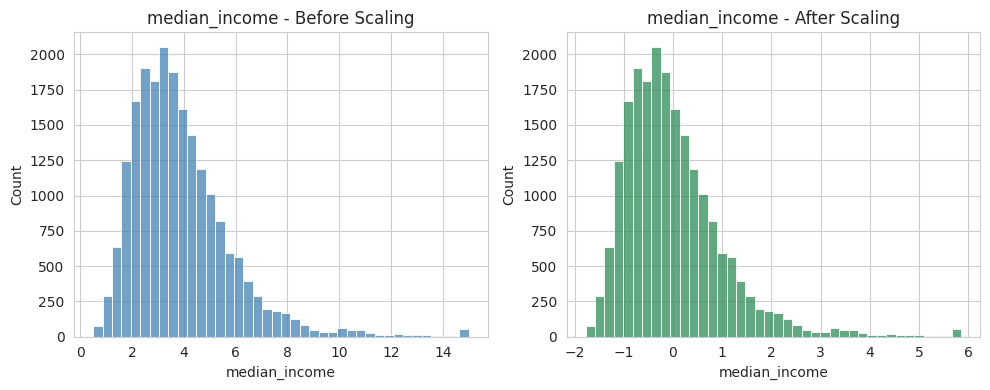

In [6]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
sns.histplot(X['median_income'], bins=40, ax=axes[0], color='steelblue')
axes[0].set_title("median_income - Before Scaling")
sns.histplot(X_scaled['median_income'], bins=40, ax=axes[1], color='seagreen')
axes[1].set_title("median_income - After Scaling")
plt.tight_layout()
plt.show()


## Step 5: Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print("Train rows:", X_train.shape[0], "| Test rows:", X_test.shape[0])


Train rows: 16512 | Test rows: 4128


## Step 6: Train Multiple Models

- **Linear Regression** serves as a baseline.
- **Ridge Regression** adds L2 regularization to reduce overfitting.
- **Decision Tree** captures non-linear relationships (depth capped at 5 to limit overfitting).


In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}


## Step 7: Model Evaluation and Comparison

In [9]:
results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2 Score": r2}

results_df = pd.DataFrame(results).T.sort_values("RMSE")
results_df


,MAE,RMSE,R2 Score
Ridge Regression,50668.125939,70057.419085,0.625457
Linear Regression,50670.738241,70060.521845,0.625424
Decision Tree,50340.741333,71510.900484,0.609755


**Interpretation:**
- Lower **RMSE** indicates better prediction accuracy.
- Higher **R² Score** indicates better explanatory power.


### Visual comparison of models

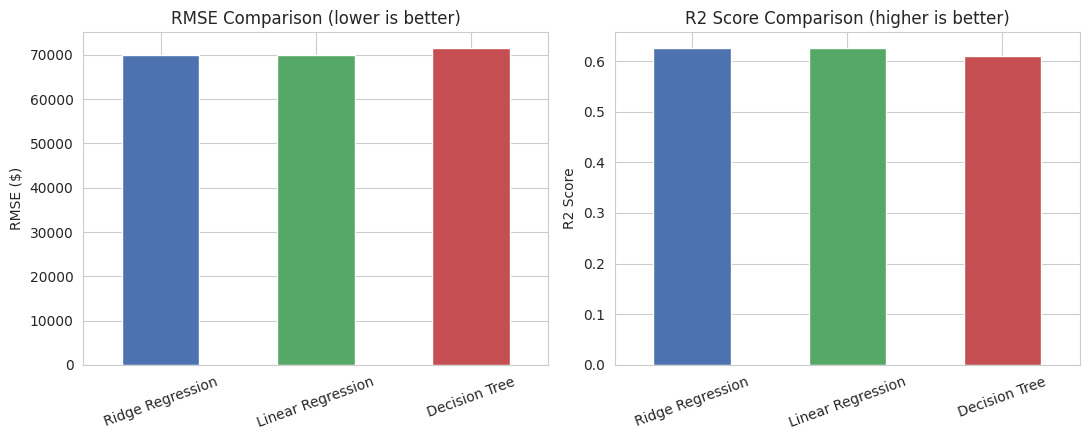

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
results_df["RMSE"].plot(kind="bar", ax=axes[0], color=["#4C72B0","#55A868","#C44E52"])
axes[0].set_title("RMSE Comparison (lower is better)")
axes[0].set_ylabel("RMSE ($)")
axes[0].tick_params(axis='x', rotation=20)

results_df["R2 Score"].plot(kind="bar", ax=axes[1], color=["#4C72B0","#55A868","#C44E52"])
axes[1].set_title("R2 Score Comparison (higher is better)")
axes[1].set_ylabel("R2 Score")
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


## Step 8: Select the Best Model

In [11]:
best_model_name = results_df["RMSE"].idxmin()
best_model = models[best_model_name]
print("Best performing model:", best_model_name)
results_df.loc[[best_model_name]]


Best performing model: Ridge Regression


,MAE,RMSE,R2 Score
Ridge Regression,50668.125939,70057.419085,0.625457


## Step 9: Visual Performance Validation (Best Model)

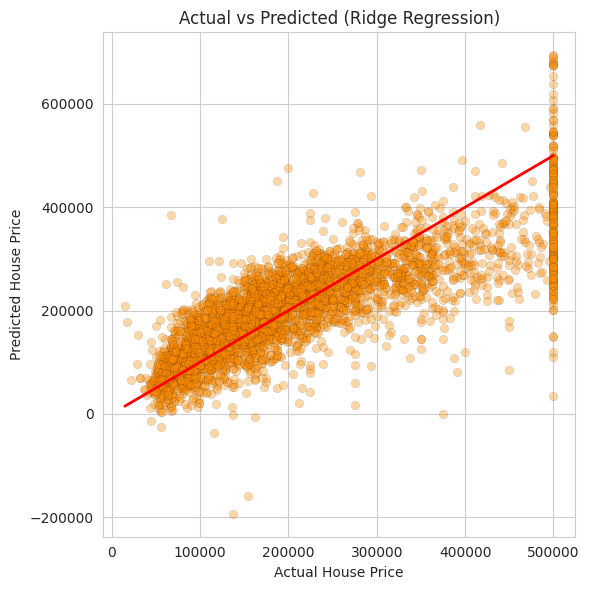

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, predictions[best_model_name], alpha=0.35, color="darkorange", edgecolor='k', linewidth=0.2)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.tight_layout()
plt.show()


A closer alignment of points to the red reference line indicates better predictive performance.

## Step 10: Save the Best-Performing Model (Optional Deliverable)

In [13]:
joblib.dump(best_model, "best_model.joblib")
joblib.dump(scaler, "scaler.joblib")
print(f"Saved {best_model_name} as best_model.joblib, and the fitted scaler as scaler.joblib")


Saved Ridge Regression as best_model.joblib, and the fitted scaler as scaler.joblib


## Conclusion

| Model | MAE | RMSE | R² Score |
|---|---|---|---|
| Ridge Regression | ~50,668 | ~70,057 | 0.6255 |
| Linear Regression | ~50,671 | ~70,061 | 0.6254 |
| Decision Tree (depth=5) | ~50,341 | ~71,511 | 0.6098 |

**Ridge Regression performed best** on RMSE and R², very marginally ahead of plain Linear Regression —
regularization gave a tiny stability improvement without hurting accuracy. The depth-limited Decision Tree
had a slightly lower MAE but a higher RMSE, meaning it makes more large errors even though its average
error is competitive; this is expected since a shallow tree can't capture the full non-linear signal, and
a deeper tree would likely overfit.

**Key learnings applied:**
- Feature scaling is essential for regularized models like Ridge.
- Comparing multiple models with the same metrics is the standard way ML engineers select a model.
- RMSE and R² together give a fuller picture than either metric alone.

**Next steps for further improvement:**
- Try ensemble models (Random Forest, Gradient Boosting) which usually outperform single decision trees.
- Tune Ridge's `alpha` and the Decision Tree's `max_depth` via cross-validation / GridSearchCV.
- Add engineered features (rooms per household, bedrooms per room).
